# Carregamento de Bibliotecas e do Dataframe

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Configuração para que todo dataFrame seja exibido no notebook no padrão brasileiro
# Mostrando os números com duas casas decimais e separador de milhar e sem notação científica
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

# Exibe todas as colunas do dataframe
pd.set_option('display.max_columns', None)

In [10]:
#Carrega o csv em uma variável do tipo pandas dataframe
df_viagem = pd.read_csv(
    '2026_Viagem.csv', 
    sep=';', 
    decimal=',', 
    encoding='latin-1', 
    parse_dates=['Período - Data de início', 'Período - Data de fim'],
    dayfirst=True  # <-- data no formato brasileiro (dd/mm/yyyy)
)

# Apresentação da Base de Dados e das perguntas
<p> Esta base foi obtida pelo portal da transparência e trata-se das viagens realizadas por servidores públicos a serviço dos diversos órgãos no ano de 2026, atualizada até dia 16/08/2026. O link para a base encontra-se no README do projeto. </p>

Como pode-se observar pelo df.info() executado anteriormente tratam-se de 22 colunas. A maioria das colunas é auto-explicativa e a bse contém pouco mais de 406 mil linhas.

Os valores monetários relacionados as quatro últimas colunas são em BRL.

As datas de inicio e fim das viagens estão no formato americano de ano-mes-dia ou também conhecido como yyyy-mm-dd

# Perguntas que gostaríamos de responder

-1 Quais órgãos públicos realizam mais viagens e concentram os maiores gastos? Como o gasto se distribui entre os órgaos e qual o custo médio por viagem ?

-2 Quais características estão associadas às viagens de maior custo? Existem viagens ou viajantes com gastos significativamente acima do padrão ?

-3 Qual é a composição dos gastos nas suas categorias : diárias, passagens, outros gastos, etc.

-4 Qual é a proporção de viagens realizadas vs não realizadas ? Qual o impacto financeiro das viagens não realizadas ? 

-5 Viagens marcadas como urgente apresentam custo médio maior do que viagens não urgentes? Existe correlação entre urgência e custo da viagem ? 

-6 Quais cargos públicos tiveram maior despesa com viagens, despesa média, duração média, quantidade de viagens e destino mais frequente? 

### 1. Visualização do dataframe

In [11]:
df_viagem

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos
0,21116870,000073/26,Realizada,SIM,Atraso na solicitação,26000,Ministério da Educação,26436,"Instituto Federal de Educação, Ciência e Tecno...",***.240.140-**,HELENA MIRANDA DA SILVA,PEDAGOGO-AREA,FG-0001,FG-0001,2026-02-25,2026-02-25,Venâncio Aires/RS,Motivo da viagem (objeto/assunto a ser tratado...,"107,83","0,00","0,00","0,00"
1,21126303,000001/26,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26236,Universidade Federal Fluminense,NaN,RITA DE CASSIA DA SILVA ALMICO,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2026-01-25,2026-07-24,Pelotas/RS,Pesquisa com colaboração de professores da Uni...,"0,00","0,00","0,00","0,00"
2,21342207,000001/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.506.203-**,CICERO RAFAEL BARBOSA CAVALCANTE PESSOA,NaN,Sargento,Sargentos,2026-01-09,2026-01-10,Washington/Estados Unidos da América,A fim de exercer o cargo de Auxiliar da Seção ...,"0,00","5.927,18","0,00","0,00"
3,21343024,000001/26,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26247,Universidade Federal de Santa Maria,***.464.017-**,RODRIGO MARINHO DE SOUZA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2026-02-28,2026-03-08,Montevidéu/Uruguai,"O docente RODRIGO MARINHO DE SOUZA, SIAPE 1296...","0,00","0,00","0,00","0,00"
4,21346664,000002/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.526.753-**,IZA NARA FREITAS RIBEIRO PESSOA,NaN,-1,Sem informação,2026-01-09,2026-01-10,Washington/Estados Unidos da América,Acompanhar militar designado para missão no ex...,"0,00","5.927,18","0,00","0,00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406078,2026000990,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.827.438-**,GABRIEL MURICCA GALIPOLO,PRESIDENTE DO BANCO CENTRAL,-1,Sem informação,2026-06-14,2026-06-14,Sem informação,"Retorno de missão oficial no exterior (Xangai,...","0,00","1.442,04","0,00","0,00"
406079,2026000995,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.231.806-**,LUCAS ALVES FREIRE,PROCURADOR DO BANCO CENTRAL,-1,Sem informação,2026-06-25,2026-06-25,Sem informação,Reunião -Correição PGBC - DPG-1 e Subprocurado...,"349,55","1.360,93","0,00","0,00"
406080,2026000998,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.359.685-**,FERNANDO RYU RAMOS KAWAOKA,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2026-06-17,2026-06-19,Sem informação,Participar de reuniões de trabalho e de Oficin...,"1.458,64","951,97","0,00","0,00"
406081,2026001027,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.216.481-**,MATHEUS RAUBER CORADIN,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2026-06-10,2026-06-11,Sem informação,"Participar, como painelista, no Fintouch 2026 ...","429,09","0,00","0,00","0,00"


### 2. Diagnóstico de qualidade

In [12]:
print("shape: ", df_viagem.shape) 
df_viagem.info()

shape:  (406083, 22)
<class 'pandas.DataFrame'>
RangeIndex: 406083 entries, 0 to 406082
Data columns (total 22 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   Identificador do processo de viagem  406083 non-null  int64         
 1   Número da Proposta (PCDP)            406083 non-null  str           
 2   Situação                             406083 non-null  str           
 3   Viagem Urgente                       406083 non-null  str           
 4   Justificativa Urgência Viagem        405907 non-null  str           
 5   Código do órgão superior             406083 non-null  int64         
 6   Nome do órgão superior               406083 non-null  str           
 7   Código órgão solicitante             406083 non-null  int64         
 8   Nome órgão solicitante               406083 non-null  str           
 9   CPF viajante                         369197 non-null  str   

## Valores "Sem informação" e "Sem informaçã":
- Conforme dados abaixo identificou-se grande quantidade de valores "Sem informaão"
- Verificar a relevância das colunas para as perguntas a serem respondidas.  
- Não há necessidade de tratamento se as colunas e esses valores não forem relevantes para as perguntas da análise.


In [13]:
# Valores nulos:
diag_nulos = pd.DataFrame({
    'faltantes': df_viagem.isna().sum(),
    'pct': (df_viagem.isna().mean() * 100).round(2),
    'distintos': df_viagem.nunique(),
})
print("Diagnóstico de dados nulos:")
display(diag_nulos[diag_nulos['faltantes'] > 0].sort_values('faltantes', ascending=False))

print("linhas com algum faltante:", df_viagem.isna().any(axis=1).sum())
print("linhas completas         :", df_viagem.notna().all(axis=1).sum())

# Contagem do valor "Sem informação":
contagem1 = (df_viagem == "Sem informação").sum()
contagem1 = contagem1[contagem1 > 0].sort_values(ascending=False)

print('\nContagem por coluna de registros com valor "Sem informação":')
print(contagem1)

# Contagem do valor "Sem informaçã":
contagem2 = (df_viagem == "Sem informaçã").sum()
contagem2 = contagem2[contagem2 > 0].sort_values(ascending=False)

print('\nContagem por coluna de registros com valor "Sem informaçã":')
print(contagem2)



Diagnóstico de dados nulos:


,faltantes,pct,distintos
Cargo,142261,"35,03",781
CPF viajante,36886,"9,08",120305
Justificativa Urgência Viagem,176,"0,04",91864
Descrição Função,5,"0,00",151


linhas com algum faltante: 156269
linhas completas         : 249814

Contagem por coluna de registros com valor "Sem informação":
Descrição Função                 191806
Justificativa Urgência Viagem    112914
Destinos                           1206
dtype: int64

Contagem por coluna de registros com valor "Sem informaçã":
Número da Proposta (PCDP)    677
dtype: int64


Utilização do método `describe()` para obter um resumo estatísticas descritivas das colunas do DataFrame, exibe dados como contagem (count), média (mean), desvio padrão (std), valor mínimo (min), quartis (25%, 50%, 75%) e valor máximo (max).

In [14]:
df_viagem.describe().round(2)

,Identificador do processo de viagem,Código do órgão superior,Código órgão solicitante,Período - Data de início,Período - Data de fim,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos
count,"406.083,00","406.083,00","406.083,00",406083,406083,"406.083,00","406.083,00","406.083,00","406.083,00"
mean,"25.326.708,72","36.745,22","33.964,94",2026-04-24 00:11:22.973677,2026-04-28 10:58:09.495496,"1.608,16","1.274,45","16,35","17,52"
min,"21.116.870,00","20.000,00","20.000,00",2026-01-01 00:00:00,2026-01-01 00:00:00,"0,00","0,00","0,00","0,00"
25%,"21.843.311,50","26.000,00","26.239,00",2026-03-13 00:00:00,2026-03-18 00:00:00,"394,14","0,00","0,00","0,00"
50%,"21.976.876,00","30.000,00","30.108,00",2026-04-27 00:00:00,2026-04-30 00:00:00,"958,86","0,00","0,00","0,00"
75%,"22.119.836,00","47.000,00","40.000,00",2026-06-07 00:00:00,2026-06-11 00:00:00,"1.710,00","1.908,09","0,00","0,00"
max,"2.026.001.079,00","84.000,00","84.000,00",2026-11-27 00:00:00,2026-12-31 00:00:00,"81.175,00","171.116,23","28.746,23","40.495,53"
std,"81.747.144,79","12.742,05","11.798,06",NaN,NaN,"2.982,50","2.938,32","248,14","157,03"


### 3. Consistência

In [15]:
# Exibe qua quantidade de vezes que cada cargo aparecem na coluna "Cargo"
df_viagem['Cargo'].value_counts()

Cargo
Informações protegidas por sigilo        59173
PROFESSOR DO MAGISTERIO SUPERIOR         22218
PROFESSOR ENS BASICO TECN TECNOLOGICO    17240
ANALISTA AMBIENTAL                       10087
AUDITOR FISCAL FEDERAL AGROPECUARIO       9680
                                         ...  
SEGUNDO TENENTE                              1
MOTOCICLISTA                                 1
EDITOR DE MIDIA AUDIOVISUAL-NI               1
VIGIA                                        1
TECNICO EM SANEAMENTO                        1
Name: count, Length: 781, dtype: int64

In [16]:
# Trasforma todas a primeira letra de cada palavra em maiúscula na coluna "Cargo" 
# Remove espaços: apaga espaços, tabulações e quebra de linha nas extremidades direita e esquerda
df_viagem['Cargo'] = df_viagem['Cargo'].str.strip().str.title()
# Exibe qua quantidade de vezes que cada cargo aparecem na coluna "Cargo"
df_viagem['Cargo'].value_counts()

Cargo
Informações Protegidas Por Sigilo        59173
Professor Do Magisterio Superior         22218
Professor Ens Basico Tecn Tecnologico    17240
Analista Ambiental                       10087
Auditor Fiscal Federal Agropecuario       9680
                                         ...  
Segundo Tenente                              1
Motociclista                                 1
Editor De Midia Audiovisual-Ni               1
Vigia                                        1
Tecnico Em Saneamento                        1
Name: count, Length: 781, dtype: int64

In [17]:
# Transforma toda primeira letra da palavra em maiuscula
# Remove espaços das extremidades: Apaga espaços, tabulações e quebras de linha nas extremidades esquerda e direita
df_viagem['Cargo'] = df_viagem['Cargo'].str.strip().str.title()
# Realiza a troca do nome do Cargo para remover inconsistência
df_viagem['Cargo'] = df_viagem['Cargo'].replace({'Artif De Eletric Comunicacoes': 'Artifice De Eletricidade E Comunicacao'})
# Exibe qua quantidade de vezes que cada cargo aparecem na coluna "Cargo"
df_viagem['Cargo'].value_counts()

Cargo
Informações Protegidas Por Sigilo        59173
Professor Do Magisterio Superior         22218
Professor Ens Basico Tecn Tecnologico    17240
Analista Ambiental                       10087
Auditor Fiscal Federal Agropecuario       9680
                                         ...  
Segundo Tenente                              1
Motociclista                                 1
Editor De Midia Audiovisual-Ni               1
Vigia                                        1
Tecnico Em Saneamento                        1
Name: count, Length: 781, dtype: int64

### 4. Duplicados

In [18]:
# Analisa se há linhas totalmente duplicadas
print("linhas totalmente duplicadas: ", df_viagem.duplicated().sum())
df_viagem[df_viagem.duplicated(keep=False)].sort_values('Identificador do processo de viagem').head()

linhas totalmente duplicadas:  0


,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos


In [19]:
# Analisa se há 'Identificador do processo de viagem' repetidos
print("Identificador do processo de viagem é único?", df_viagem['Identificador do processo de viagem'].is_unique)
print("Identificador do processo de viagem repetidos: ", df_viagem['Identificador do processo de viagem'].duplicated().sum())

Identificador do processo de viagem é único? True
Identificador do processo de viagem repetidos:  0


### 5. Faltantes

In [20]:
print("itens faltantes na coluna Cargo", df_viagem['Cargo'].isna().sum())
print('pct de itens faltantes na coluna Cargo: ', (df_viagem['Cargo'].isna().mean() * 100).round(2))
print("itens distintos na coluna Cargo: ", df_viagem['Cargo'].nunique())

itens faltantes na coluna Cargo 142261
pct de itens faltantes na coluna Cargo:  35.03
itens distintos na coluna Cargo:  781


Devido a alta porcentagem de itens faltantes na coluna Cargo **(34,84%)**. O ideal seria ajustar os valores ausentes desta coluna para "Não Identificado".<br>
Pois remover está quantidade de itens poderia enviesar a análise retirando mais de um terço da quantidade de itens.

In [21]:
# Substituindo valores nulos na coluna 'Cargo' utilizando **apply e lambda**
df_viagem['Cargo'] = df_viagem['Cargo'].apply(lambda x: 'Não Identificado' if pd.isna(x) else x)
df_viagem['Cargo'].value_counts()

Cargo
Não Identificado                         142261
Informações Protegidas Por Sigilo         59173
Professor Do Magisterio Superior          22218
Professor Ens Basico Tecn Tecnologico     17240
Analista Ambiental                        10087
                                          ...  
Segundo Tenente                               1
Motociclista                                  1
Editor De Midia Audiovisual-Ni                1
Vigia                                         1
Tecnico Em Saneamento                         1
Name: count, Length: 782, dtype: int64

### 6. Registros sem movimentação financeira

A inspeção inicial de df_viagem revelou registros onde todos os valores monetários constam como zerados. O filtro identificou 24.293 linhas nessa condição.

Para verificar se representam ausência real de desembolso, os identificadores desses processos foram confrontados com a tabela 2026_Pagamento. As colunas de identificador têm o mesmo tipo (int64), permitindo a comparação direta. O cruzamento retornou conjunto vazio: **nenhum desses processos possui pagamento registrado**.

A tabela de pagamentos não registrou viagens sem desembolso, confirmando que os valores zerados refletem ausência de despesa — e não falha de preenchimento. Assim, esses registros foram excluídos do escopo da nossa análise.

A exclusão considerou ainda o efeito sobre as medidas estatísticas. Com 24.293 linhas (cerca de 6% da base), a manutenção desses registros deslocaria média e mediana para baixo, produzindo um custo médio enviesado pela inclusão de viagens sem custeio efetivo.


In [22]:
# Criando um filtro para listar somente as colunas de valores monetários:
colunas_valores_monetarios = ["Valor diárias", "Valor passagens", "Valor devolução", "Valor outros gastos"]

#Filtrando as linhas onde todos os valores monetários estão zerados:
df_viagem_zerados = df_viagem[df_viagem[colunas_valores_monetarios].eq(0).all(axis=1)]
print(f'Quantidade de linhas e colunas onde todos os valores de gastos são zero: {df_viagem_zerados.shape[0]} linhas e {df_viagem_zerados.shape[1]} colunas \n')

Quantidade de linhas e colunas onde todos os valores de gastos são zero: 24293 linhas e 22 colunas 



Checando se os identificadores do processo de viagem de df_zerados constam nos dados da tabela 2026_Pagamento:

In [23]:
# Abrindo o arquivo 2026_Pagamento com ajuste dos valores com casa decimal:
df_pagamento = pd.read_csv('2026_Pagamento.csv', sep=';', decimal=',', encoding='latin-1')
#display(df_pagamento.head(3))

# Checando se os dados dos id's (identificadores de viagem) das duas tabelas são do mesmo tipo e podem ser comparados: 
print('\nTipo de dados das colunas a serem comparadas:')
print(df_viagem["Identificador do processo de viagem"].dtype)
print(df_pagamento["Identificador do processo de viagem"].dtype)

## Checando se na tabela de pagamentos constam os Id's refrente aos registros com todos os valores monetarios zerados:
 
# Criando série dos id's de df_viagem_zerados
id_zerados = df_viagem_zerados['Identificador do processo de viagem']

df_pag_zerados = df_pagamento[
    df_pagamento["Identificador do processo de viagem"].isin(id_zerados)
]

print("\nDataframe de checagem:")
print(f'Processos zerados com pagamento registrado: {len(df_pag_zerados)}')
df_pag_zerados


Tipo de dados das colunas a serem comparadas:
int64
int64

Dataframe de checagem:
Processos zerados com pagamento registrado: 0


,Identificador do processo de viagem,Número da Proposta (PCDP),Código do órgão superior,Nome do órgão superior,Codigo do órgão pagador,Nome do órgao pagador,Código da unidade gestora pagadora,Nome da unidade gestora pagadora,Tipo de pagamento,Valor


**Exclusão das linhas onde todos os valores monetários constam como zerados:**

In [24]:
valores_monetarios = ["Valor diárias", "Valor passagens", "Valor devolução", "Valor outros gastos"]

filtro = ~df_viagem[valores_monetarios].eq(0).all(axis=1)
df_viagem_limpo = df_viagem[filtro].copy()

print(f'Antes: {len(df_viagem)} | Depois: {len(df_viagem_limpo)} | Removidas: {len(df_viagem) - len(df_viagem_limpo)}')

Antes: 406083 | Depois: 381790 | Removidas: 24293


In [25]:
df_viagem = df_viagem_limpo
print("Shape:",df_viagem.shape)

Shape: (381790, 22)


### 7. Inclusão das colunas Gasto Total e Gasto líquido

In [26]:
# Incluindo as colunas Gasto Total e Gasto líquido
colunas_gastos = ["Valor diárias", "Valor passagens", "Valor outros gastos"]
df_viagem['Gasto total'] = df_viagem[colunas_gastos].sum(axis=1)
df_viagem['Gasto líquido'] = (
    df_viagem["Gasto total"]
    - df_viagem['Valor devolução']
)
print("shape", df_viagem.shape)
df_viagem.head(3)

shape (381790, 24)


,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Gasto total,Gasto líquido
0,21116870,000073/26,Realizada,SIM,Atraso na solicitação,26000,Ministério da Educação,26436,"Instituto Federal de Educação, Ciência e Tecno...",***.240.140-**,HELENA MIRANDA DA SILVA,Pedagogo-Area,FG-0001,FG-0001,2026-02-25,2026-02-25,Venâncio Aires/RS,Motivo da viagem (objeto/assunto a ser tratado...,"107,83","0,00","0,00","0,00","107,83","107,83"
2,21342207,000001/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.506.203-**,CICERO RAFAEL BARBOSA CAVALCANTE PESSOA,Não Identificado,Sargento,Sargentos,2026-01-09,2026-01-10,Washington/Estados Unidos da América,A fim de exercer o cargo de Auxiliar da Seção ...,"0,00","5.927,18","0,00","0,00","5.927,18","5.927,18"
4,21346664,000002/26,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.526.753-**,IZA NARA FREITAS RIBEIRO PESSOA,Não Identificado,-1,Sem informação,2026-01-09,2026-01-10,Washington/Estados Unidos da América,Acompanhar militar designado para missão no ex...,"0,00","5.927,18","0,00","0,00","5.927,18","5.927,18"


### 8. Resumo Estatístico para as colunas de valores dos gastos:

In [29]:
# Resumo estatísitco das colunas de gastos:
colunas_gastos = ["Valor diárias", "Valor passagens", "Valor devolução", "Valor outros gastos", "Gasto total", "Gasto líquido"]
resumo_estatisco = df_viagem[colunas_gastos].describe()
resumo_estatisco

,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Gasto total,Gasto líquido
count,"381.790,00","381.790,00","381.790,00","381.790,00","381.790,00","381.790,00"
mean,"1.710,49","1.355,54","17,39","18,64","3.084,67","3.067,28"
std,"3.047,34","3.012,17","255,88","161,88","4.800,49","4.773,19"
min,"0,00","0,00","0,00","0,00","0,01","-837,50"
25%,"395,68","0,00","0,00","0,00","674,96","674,96"
50%,"1.050,78","0,00","0,00","0,00","1.571,60","1.571,60"
75%,"1.782,50","2.090,60","0,00","0,00","4.075,70","4.050,80"
max,"81.175,00","171.116,23","28.746,23","40.495,53","182.273,47","182.273,47"


> **Registros com gasto líquido negativo.** Foram identificados 5 registros (0,001% da base, saldo de R$ -2.235,00) em que o valor devolvido supera o gasto total. As diferenças concentram-se em múltiplos de R$ 0,50, compatíveis com valores de diárias. Todos os casos são de viagens realizadas e podem sugerir retificação do valor da viagem posterior ao registro da devolução (por exemplo, antecipação de retorno ou supressão de trecho). Dado o volume residual e o impacto de apenas 0,0002% sobre o gasto líquido total (ver análise abaixo), os registros foram mantidos sem ajuste.

In [30]:
neg = df_viagem['Gasto líquido'] < 0
if neg.any():
    display(df_viagem.loc[neg, ['Identificador do processo de viagem', 'Situação',
                                'Gasto total', 'Valor devolução', 'Gasto líquido']])

print(f'{neg.sum()} registros ({100*neg.mean():.3f}% da base)')
print(f'Soma dos saldos negativos: R$ {df_viagem.loc[neg, "Gasto líquido"].sum():,.2f}')
print(f'Impacto no gasto líquido total: {100*abs(df_viagem.loc[neg, "Gasto líquido"].sum()) / df_viagem["Gasto líquido"].sum():.4f}%')
display(df_viagem.loc[neg, 'Situação'].value_counts())

,Identificador do processo de viagem,Situação,Gasto total,Valor devolução,Gasto líquido
7628,21721603,Realizada,"9.708,39","10.088,39","-380,00"
249019,22038874,Realizada,"1.241,64","1.691,64","-450,00"
252873,22044154,Realizada,"1.200,00","1.600,00","-400,00"
306706,22122852,Realizada,"1.625,78","2.463,28","-837,50"
316232,22137840,Realizada,"394,14","561,64","-167,50"


5 registros (0.001% da base)
Soma dos saldos negativos: R$ -2,235.00
Impacto no gasto líquido total: 0.0002%


Situação
Realizada    5
Name: count, dtype: int64

### Tratamento de outliers

Optou-se por **não remover valores extremos** na etapa de limpeza. A aplicação do critério do intervalo interquartil (IQR) à coluna `Gasto total` sinalizaria 19.477 registros (5,10% da base) acima do limite superior de R$ 9.176,81, volume incompatível com a noção de anomalia pontual.

A razão é metodológica: As despesas com viagens seguem distribuição fortemente assimétrica, com grande concentração em valores baixos e cauda longa à direita, padrão característico de variáveis monetárias, em que existe um piso natural (zero) mas não um teto. O critério IQR, por pressupor distribuição aproximadamente simétrica, não se ajusta a esse comportamento. Como se vê nos cálculos abaixo, o limite obtido situa-se mais próximo ao percentil 95, o que confirma que ele apenas trunca a cauda superior.

Nesse contexto, os valores acima do limite não representam erro de registro, mas viagens legitimamente onerosas (deslocamentos internacionais, missões prolongadas ou comitivas). Sua exclusão eliminaria justamente os registros de maior relevância orçamentária, distorcendo a mensuração do gasto público.

In [38]:
# --- Critério IQR ---
x = df_viagem['Gasto total']
q1, q3, p95 = x.quantile([.25, .75, .95])
#quantile calculas os percentis pedidos
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"Q1={q1:.2f} || Q3={q3:.2f} ||  IQR={iqr:.2f} || P95={p95:.2f} ")
print(f"limites: [{lim_inf:.2f}, {lim_sup:.2f}]")

#acima_lim = (x < lim_inf) | (x > lim_sup)
#df_acima_lim =df_viagem[acima_lim]
#print("Registros acima do limite:", acima_lim.sum())
#df_acima_lim.nlargest(10, 'Gasto total')[
#    ['Identificador do processo de viagem',"Situação", "Viagem Urgente", "Valor diárias", "Valor passagens", "Gasto total"]]

Q1=674.96 || Q3=4075.70 ||  IQR=3400.74 || P95=9240.09 
limites: [-4426.15, 9176.81]


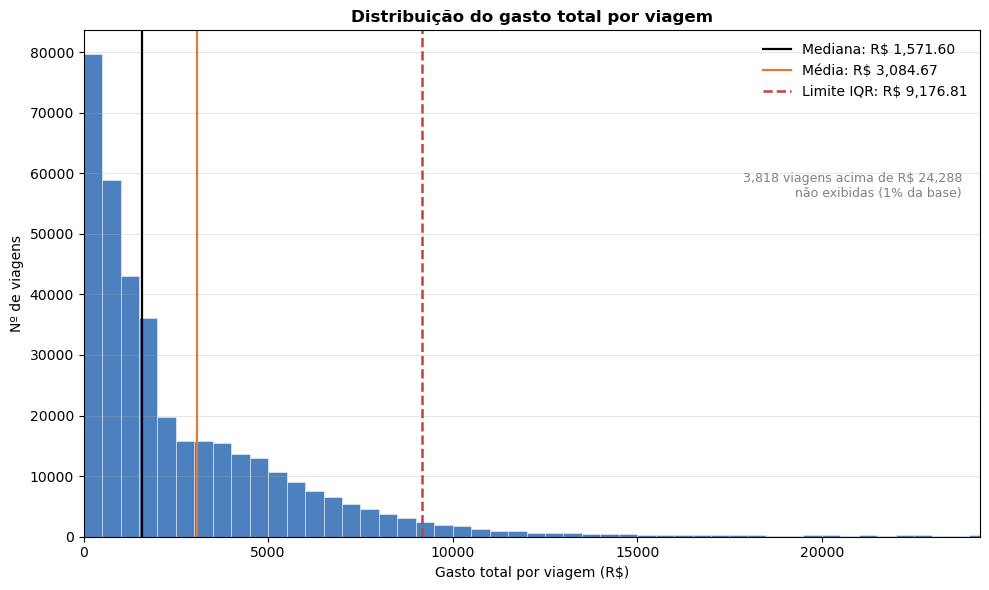

In [39]:
# ------ Histograma -------

x = df_viagem['Gasto total']

q1, q3 = x.quantile([0.25, 0.75])
lim_sup = q3 + 1.5 * (q3 - q1)
corte = x.quantile(0.99)          # limite do eixo, apenas para visualização
fora = (x > corte).sum()

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(x, bins=np.arange(0, corte + 500, 500), color='#2e6ab3',
        alpha=0.85, edgecolor='white', linewidth=0.4)

ax.axvline(x.median(), color='black', lw=1.6,
           label=f'Mediana: R$ {x.median():,.2f}')
ax.axvline(x.mean(), color='#e07b39', lw=1.6,
           label=f'Média: R$ {x.mean():,.2f}')
ax.axvline(lim_sup, color='#c1443c', ls='--', lw=1.8,
           label=f'Limite IQR: R$ {lim_sup:,.2f}')

ax.set_xlim(0, corte)
ax.set_xlabel('Gasto total por viagem (R$)')
ax.set_ylabel('Nº de viagens')
ax.set_title('Distribuição do gasto total por viagem', fontweight='bold')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

ax.text(0.98, 0.72, f'{fora:,} viagens acima de R$ {corte:,.0f}\nnão exibidas (1% da base)',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

---
# ANÁLISE #4

## _Qual é a proporção de viagens realizadas e não realizadas, e qual o impacto financeiro das viagens não realizadas?_

Para tentar responder a essas perguntas iniciamos com análises por agregação da tabela de viagens segundo o campo Situação, que classifica cada processo como realizado ou não realizado e resultaram em dois quadros que resumem cada situação considerando o gasto total (Resumo Comparativo entre Viagens Realizadas e Não Realizadas) e também os valores devolvidos (Valor Devolvido por Viagens Realizadas e Não Realizadas)  

As proporções (`% das viagens`, `% do gasto`) dividem cada linha pelo total da coluna e respondem à questão do peso numérico e financeiro de cada grupo.    

Além da média, incluem-se mediana e percentil 95, dada a assimetria da distribuição de gastos, em que valores extremos comprometem a representatividade da média. A razão média/mediana sintetiza essa assimetria.

No quadro de devoluções, as estatísticas de posição são calculadas apenas sobre registros com devolução positiva (`s[s > 0]`) — do contrário, os milhares de zeros diluiriam as medidas.

> Viagens pendentes na data de extração dos dados. Identificaram-se 147 registros com início previsto para data posterior a 16/08/2026, todos classificados como não realizados. Trata-se de viagens ainda não ocorridas na data de extração da base, e não de cancelamentos. Esses registros foram excluídos da análise de cancelamentos, que passa a considerar 4.731 processos (1,24% da base). Ressalve-se que viagens encerradas nos dias imediatamente anteriores ao corte podem igualmente estar com situação pendente de atualização, o que sugere leve superestimação residual da taxa de cancelamento.

In [40]:
#TRATAMENTO DAS VISAGENS PENDENTES:

# Vetorização com np.where: a condição é avaliada de uma só vez sobre todo o array,
# em código compilado (C), sem laço em Python. Em ~380 mil registros, alternativas
# linha a linha como .apply() ou iterrows() seriam ordens de magnitude mais lentas,
# pois exigem uma chamada de função Python por registro.

DATA_CORTE = pd.Timestamp('2026-08-16')

manter = np.where(
    (df_viagem['Situação'] == 'Não realizada') &
    (df_viagem['Período - Data de início'] >= DATA_CORTE),
    False, True
)
df_analise = df_viagem[manter].copy()

print(f'Removidos: {len(df_viagem) - len(df_analise)} registros')
print(f'Base final: {len(df_analise):,}')

Removidos: 147 registros
Base final: 381,643



RESUMO COMPARATIVO ENTRE VIAGENS REALIZADAS E NÃO REALIZADAS:


,Qtde de viagens,Gasto total (R$),Gasto médio (R$),Gasto mediano (R$),Gasto P95 (R$),Maior gasto (R$),% das viagens,% do gasto,Assimetria (méd/med)
Situação,,,,,,,,,
Realizada,376912,"1.155.905.230,69","3.066,78","1.566,92","9.236,41","182.273,47","98,76","98,18","1,96"
Não realizada,4731,"21.408.379,58","4.525,13","3.437,23","9.551,21","151.969,17","1,24","1,82","1,32"



VALOR DEVOLVIDO POR VIAGENS REALIZADAS E NÃO REALIZADAS:


,Qtde de viagens,Viagens com devolução,Total devolvido (R$),Devolução média (R$),Devolução mediana (R$),Devolução P95 (R$),Maior devolução (R$),% viagens c/ devolução,% do gasto recuperado
Situação,,,,,,,,,
Realizada,376912,9407,"3.657.288,87","388,78","97,34","1.514,77","18.295,42","2,50","0,32"
Não realizada,4731,1638,"2.981.605,34","1.820,27","1.219,96","5.207,15","28.746,23","34,62","13,93"


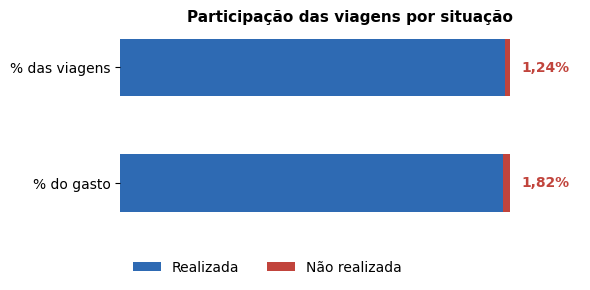

In [49]:
# QUADRO RESUMO DE VIAGENS REALIZADAS E NÃO REALIZADAS
print("\nRESUMO COMPARATIVO ENTRE VIAGENS REALIZADAS E NÃO REALIZADAS:")

resumo_por_situacao = df_analise.groupby("Situação").agg(
    **{
        'Qtde de viagens':        ('Identificador do processo de viagem', 'count'),
        'Gasto total (R$)':       ('Gasto total', 'sum'),
        'Gasto médio (R$)':       ('Gasto total', 'mean'),
        'Gasto mediano (R$)':     ('Gasto total', 'median'),
        'Gasto P95 (R$)':         ('Gasto total', lambda s: s.quantile(0.95)),
        'Maior gasto (R$)':       ('Gasto total', 'max'),
    }
).assign(**{
    '% das viagens':  lambda d: d['Qtde de viagens'] / d['Qtde de viagens'].sum() * 100,
    '% do gasto':     lambda d: d['Gasto total (R$)'] / d['Gasto total (R$)'].sum() * 100,
    'Assimetria (méd/med)': lambda d: d['Gasto médio (R$)'] / d['Gasto mediano (R$)'],
}).sort_values('Gasto total (R$)', ascending=False)

display(resumo_por_situacao)


# QUADRO RESUMO DOS VALORES DEVOLVIDOS POR SITUAÇÃO (REALIZADA E NÃO REALIZADA)

print("\nVALOR DEVOLVIDO POR VIAGENS REALIZADAS E NÃO REALIZADAS:")

vr_devolvido_por_situacao = df_analise.groupby("Situação").agg(
    **{
        'Qtde de viagens':          ('Valor devolução', 'size'),
        'Viagens com devolução':    ('Valor devolução', lambda s: (s > 0).sum()),
        'Total devolvido (R$)':     ('Valor devolução', 'sum'),
        'Devolução média (R$)':     ('Valor devolução', lambda s: s[s > 0].mean()),
        'Devolução mediana (R$)':   ('Valor devolução', lambda s: s[s > 0].median()),
        'Devolução P95 (R$)':       ('Valor devolução', lambda s: s[s > 0].quantile(0.95)),
        'Maior devolução (R$)':     ('Valor devolução', 'max'),
        '_gasto':                   ('Gasto total', 'sum'), # criada para viabilizar o indicador `% do gasto recuperado`
                                                            #(foi descartada ao final)
    }
).assign(**{
    '% viagens c/ devolução':  lambda d: d['Viagens com devolução'] / d['Qtde de viagens'] * 100,
    '% do gasto recuperado':   lambda d: d['Total devolvido (R$)'] / d['_gasto'] * 100,
}).sort_values('Total devolvido (R$)', ascending=False).drop(columns='_gasto')

display(vr_devolvido_por_situacao)



# --- Gráfico com a participação de viagens realizadas e não realizadas ---

r = resumo_por_situacao.sort_values('% das viagens', ascending=False)
grupos = r.index.tolist()                    # maior grupo primeiro
metricas = ['% das viagens', '% do gasto']
valores = r[metricas].T                      # linhas = métricas, colunas = grupos

cores = ['#2e6ab3', '#c1443c', '#e07b39', '#6a994e']  # suporta mais de 2 situações

fig, ax = plt.subplots(figsize=(6, 3.2))
y = np.arange(len(metricas))
esquerda = np.zeros(len(metricas))

for i, g in enumerate(grupos):
    ax.barh(y, valores[g], left=esquerda, height=0.5,
            color=cores[i % len(cores)], label=g)
    esquerda += valores[g].values

# Rótulos dos grupos minoritários, à direita da barra
for i, g in enumerate(grupos[1:], start=1):
    for j, v in enumerate(valores[g]):
        ax.annotate(f'{v:.2f}%'.replace('.', ','),
                    xy=(100, j), xytext=(8, 0), textcoords='offset points',
                    va='center', color=cores[i % len(cores)], fontweight='bold')

ax.set_yticks(y); ax.set_yticklabels(metricas)
ax.set_xlim(0, 118)
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title('Participação das viagens por situação', fontweight='bold', fontsize=11)
ax.legend(frameon=False, loc='lower left', bbox_to_anchor=(0, -0.35), ncol=len(grupos))
for s in ['top', 'right', 'left', 'bottom']:
    ax.spines[s].set_visible(False)

plt.tight_layout(); plt.show()

### Proporção de viagens realizadas e não realizadas

Em 381.643 processos de viagem, o cancelamento é exceção: 98,76% dos afastamentos autorizados se concretizaram. Apenas 4.731 viagens não foram realizadas. Esse volume aparentemente marginal, no entanto, não se traduz proporcionalmente quando se observa o dinheiro envolvido.

### Viagens não realizadas: baixa incidência, alto custo unitário e recuperação limitada

As viagens não realizadas somam 1,24% dos processos (4.731 de 381.643), mas 1,82% do gasto, com R$ 21,41 milhões comprometidos.

**São sistematicamente mais caras.** O gasto mediano das canceladas (R$ 3.437,23) supera em 119% o das realizadas (R$ 1.566,92). Por ser a diferença entre medianas maior que entre médias, o padrão não decorre de casos extremos. Os percentis 95 são próximos (R$ 9.551 e R$ 9.236): ambos os grupos têm teto semelhante, mas faltam viagens de baixo valor entre as canceladas. A hipótese mais consistente é de composição, cancelamentos com custo concentram-se em deslocamentos complexos, com passagem já emitida.

**A devolução reage ao cancelamento, mas recupera pouco.** Entre as não realizadas, 34,62% tiveram devolução, contra 2,50% das realizadas (frequência 14 vezes maior). A mediana devolvida também é superior (R$ 1.219,96 contra R$ 97,34), indicando que a restituição em viagens realizadas é majoritariamente residual. Ainda assim, recuperou-se apenas 13,93% do valor comprometido, e dois terços dos cancelamentos (3.093 processos) não registraram devolução.

**Resultado líquido:** R$ 18,43 milhões em viagens que não se realizaram — 1,57% do gasto total da base, conforme código descrito abaixo.

In [42]:
# Resultado líquido das viagens não realizadas
nr = df_analise[df_analise['Situação'] == 'Não realizada']

comprometido = nr['Gasto total'].sum()
devolvido    = nr['Valor devolução'].sum()
liquido      = nr['Gasto líquido'].sum()
base_total   = df_analise['Gasto total'].sum()

print('VIAGENS NÃO REALIZADAS — RESULTADO LÍQUIDO')
resultado_liq = pd.DataFrame({
    'Indicador': ['Processos/viagens não realizados',
                  'Gasto total comprometido (R$)',
                  'Valor devolvido (R$)',
                  'Gasto líquido (R$)',
                  '% do líquido no gasto total da base',
                  '% do comprometido recuperado'],
    'Valor': [f'{len(nr):,}',
              f'{comprometido:,.2f}',
              f'{devolvido:,.2f}',
              f'{liquido:,.2f}',
              f'{100*liquido/base_total:.2f}%',
              f'{100*devolvido/comprometido:.2f}%']
})
display(resultado_liq)

VIAGENS NÃO REALIZADAS — RESULTADO LÍQUIDO


,Indicador,Valor
0,Processos/viagens não realizados,"4,731"
1,Gasto total comprometido (R$),"21,408,379.58"
2,Valor devolvido (R$),"2,981,605.34"
3,Gasto líquido (R$),"18,426,774.24"
4,% do líquido no gasto total da base,1.57%
5,% do comprometido recuperado,13.93%


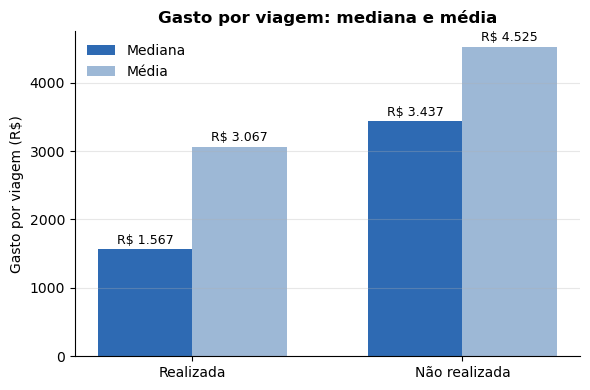

In [50]:
fig, ax = plt.subplots(figsize=(6, 4))

grupos = ['Realizada', 'Não realizada']
mediana = [1566.92, 3437.23]
media   = [3066.78, 4525.13]
x = np.arange(len(grupos)); larg = 0.35

b1 = ax.bar(x - larg/2, mediana, larg, color='#2e6ab3', label='Mediana')
b2 = ax.bar(x + larg/2, media, larg, color='#9db8d6', label='Média')

for b in list(b1) + list(b2):
    ax.annotate(f'R$ {b.get_height():,.0f}'.replace(',', '.'),
                (b.get_x() + b.get_width()/2, b.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(grupos)
ax.set_ylabel('Gasto por viagem (R$)')
ax.set_title('Gasto por viagem: mediana e média', fontweight='bold')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

# ANÁLISE #1

## Quais órgãos públicos realizam mais viagens e concentram os maiores gastos? 

Vamos usar o groupby para consolidar os dados de interesse nas categorias de cada ministério e visualizar primeiro em formato de tabela quem são os órgãos com maiores gastos.

In [ ]:
#Filtrando e agrupando
df_valores_de_viagens_agrupados_por_orgao = df_viagem[['Nome do órgão superior', 'Valor diárias', 'Valor passagens', 'Valor outros gastos', 'Gasto total']].groupby(["Nome do órgão superior"]).sum()

#Ordenando
df_valores_de_viagens_agrupados_por_orgao.sort_values(by='Gasto total', inplace=True, ascending=False)

display(df_valores_de_viagens_agrupados_por_orgao)

Agora para termos uma idéia visual vamos fazer um barplot dos dados de Gasto total:

In [ ]:
type(df_valores_de_viagens_agrupados_por_orgao)
plt.figure(figsize=(18, 12))
sns.barplot(data=df_valores_de_viagens_agrupados_por_orgao, x='Gasto total',y='Nome do órgão superior')
plt.show()

Neste gráfico pode-se ver claramente como que os três órgãos que mais gastam com viagens estão ordens de grandeza acima do gasto de outros órgãos do governo. Vamos então comparar os 10% que mais gastam contra os 90% que menos gastam.

In [ ]:
# Primeiramente vamos determinar os 10% top gastadores
df_q1 = df_valores_de_viagens_agrupados_por_orgao       #sugar coating, só pra não ficar com uma variável enorme aqui
N_OF_TOP_10 = len(df_q1.index) // 10
#df_q1[:N_OF_TOP_10]

#Vamos agora consolidar os gastos desta categoria
GASTO_TOTAL_TOP_10 = df_q1[:N_OF_TOP_10]['Gasto total'].sum() 
print(f"Gasto do top 10% : {GASTO_TOTAL_TOP_10}")

#Agora consolidemos o gasto dos BOTTOM 90
GASTO_TOTAL_BOTTOM_90 = df_q1[N_OF_TOP_10:len(df_q1.index)]['Gasto total'].sum()
print(f"Gasto dos 90% complementares: {GASTO_TOTAL_BOTTOM_90}")

# ANÁLISE #6

## Quais cargos públicos tiveram maior despesa com viagens, despesa média, duração média, quantidade de viagens e destino mais frequente? 
<p>Nesta análise, agrupamos as viagens por "Cargo" e obtivemos os valores da despesa média, duração média, despesas totais, destino mais frequentes e número de viagens por cada um dos Cargos filtrado pelos cargos que tiveram uma representatividade maior que 1%. </p>

- Identificamos que 140.875 viagens não constam o cargo e foi classificada como "Não identificado". Sendo que as viagens geradas por esta classificação gerou uma despesa total de R$ 483.813.846,56 com despesa média de R$ 3.434,35, duração média da viagem superior a 4 dias e meio e o destino mais frequente foi Brasília/DF.<br><br>
- De mesmo modo foi observado, uma alta quantidade de viagens classificadas como "Informações Protegidas Por Sigilo" sendo 62.627 viagens com uma despesa total de 218.287.490,61 com média de despesas de R$ 3.484,52 e duração média de 7 dias e meio.


### Resumo de viagens por cargo público

In [ ]:
# Incluindo as colunas "Mês da viagem" e "Dias de viagem"
df_viagem["Mês da viagem"] = df_viagem["Período - Data de início"].dt.month_name()
df_viagem["Dias de viagem"] = (df_viagem["Período - Data de fim"] - df_viagem["Período - Data de início"]).dt.days

# Criando nova coluna de despesas
df_viagem["Despesas"] = df_viagem["Valor diárias"] + df_viagem["Valor passagens"] + df_viagem["Valor outros gastos"]

# Criando tabela consolidada
df_viagem_consolidado = (
    df_viagem
    .groupby('Cargo')
    .agg(
        despesa_media=('Despesas', 'mean'),
        duracao_media=('Dias de viagem','mean'),
        despesas_totais=('Despesas', 'sum'),
        destino_mais_frequente=('Destinos',pd.Series.mode),
        n_viagens=('Nome', 'count')
        )
    .reset_index()
    .sort_values(by='despesas_totais', ascending=False)
)

# Filtrando tabela consolidade por cargos relevantes (> 1% das viagens)
df_cargos = df_viagem['Cargo'].value_counts(normalize=True).reset_index()
cargos_relevantes = df_cargos.loc[df_cargos['proportion'] > 0.01, 'Cargo']
filtro = df_viagem_consolidado['Cargo'].isin(cargos_relevantes)

# Chegando na tabela final - consolidada e filtrada
df_cargos_consolidado = df_viagem_consolidado[filtro].sort_values(by='n_viagens', ascending=False)

display(df_cargos_consolidado)

### Gráfico de viagens por cargo público

In [ ]:
import matplotlib.pyplot as plt

# Criando a figura
fig, ax = plt.subplots(figsize=(16, 6))

# Plotando o gráfico
ax.barh(df_cargos_consolidado['Cargo'], df_cargos_consolidado['n_viagens'], color='#49deac')
ax.invert_yaxis()

# Ajustando o gráfico
ax.set_facecolor('#3b3b47')
fig.suptitle('Viagens por cargo público (2026)')
plt.figtext(0.79, 0.89, 'Fonte: Portal da Transparência', fontsize=8)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.yticks(fontsize=8)
plt.xlabel('Número de viagens')

# Exibindo o gráfico
plt.show()